# Exploración Inicial de los Datos (EDA)

In [3]:
# imports
import pandas as pd
import numpy as np


# graficos
import matplotlib.pyplot as plt
import seaborn as sns

____
## Importación de datos

In [4]:
# Crear dataframe + read csv
df_marketing = pd.read_csv(r"C:\Users\ramir\OneDrive\Escritorio\Simulador\Desafiio_2\Bank_Marketing_Raw-01_Jun.csv", sep=';')

In [5]:
# Revertir el error de exportación: Convertir los ceros en la edad de nuevo a NULL (NaN)
df_marketing['age'] = df_marketing['age'].replace(0, np.nan)

In [6]:
display(df_marketing)

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10982,10983,40.0,management,married,secondary,no,8486,no,no,unknown,6,may,260,3,-1,0,unknown,no
10983,10984,53.0,management,married,tertiary,no,20772,no,no,cellular,4,feb,715,1,-1,0,unknown,no
10984,10985,55.0,blue-collar,married,primary,no,3297,yes,yes,telephone,30,apr,96,1,-1,0,unknown,no
10985,10986,41.0,management,married,tertiary,no,9,yes,no,cellular,22,jul,82,3,-1,0,unknown,no


## Análisis Estadístico


### 1. Estructura General del Dataset y Tipos de DatosDimensión del Dataset: 
* El archivo contiene 10,987 registros y 18 columnas. Esto nos da una base de datos más grande (345 registros más) en comparación con el desafío anterior.

* Tipos de Variables: El set de datos combina variables numéricas (int64, float64) y categóricas (object).

In [7]:
print(f"Registros: {len(df_marketing)}")
print(f"Columnas: {df_marketing.shape[1]}")
print("\nTipos de datos:")
print(df_marketing.dtypes)

Registros: 10987
Columnas: 18

Tipos de datos:
id             int64
age          float64
job           object
marital       object
education     object
default       object
balance        int64
housing       object
loan          object
contact       object
day            int64
month         object
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome      object
deposit       object
dtype: object


### 2. Análisis Estadístico Descriptivo de Variables NuméricasAnomalía en la Edad: 
* La variable age tenía un límite inferior erróneo de 0 años debido a que al importar los datos, se transformó los valores vacíos (NULL) en ceros de forma automática. Una vez corregido este error, devolviendo los ceros a su estado nulo original, se observa que el valor mínimo real de edad es de 18 años.

* Dispersión en el Balance: El promedio de saldo es de $1,538.16, pero la desviación estándar es muy alta ($3,240.01) y la mediana es de solo $556.00. Esto indica que la mayoría de la gente tiene saldos bajos y que existen valores atípicos (outliers) muy altos de hasta $81,204. También hay valores negativos (mínimo de -$6,847), lo que refleja cuentas sobregiradas.

* Variables de Campaña: La duración media de las llamadas es de 374.18 segundos (unos 6.2 minutos). La mitad de las llamadas duran menos de 256 segundos, pero el máximo llega a casi una hora (3,881 segundos), mostrando llamadas atípicas muy largas.

In [8]:
# Columnas numéricas clave para el negocio
cols_numericas = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [9]:
print("--- Estadísticos Descriptivos Numéricos ---")
# .describe() calcula automáticamente: count, mean, std, min, 25%, 50% (mediana), 75% y max
resumen_num = df_marketing[cols_numericas].describe().T
print(resumen_num)

--- Estadísticos Descriptivos Numéricos ---
            count         mean          std     min    25%    50%     75%  \
age       10977.0    41.263004    11.952308    18.0   32.0   39.0    49.0   
balance   10987.0  1538.162738  3240.007771 -6847.0  125.0  556.0  1723.0   
day       10987.0    15.651952     8.424481     1.0    8.0   15.0    22.0   
duration  10987.0   374.183763   348.493183     2.0  139.0  256.0   501.0   
campaign  10987.0     2.505233     2.725176     1.0    1.0    2.0     3.0   
pdays     10987.0    51.659052   109.033750    -1.0   -1.0   -1.0    40.0   
previous  10987.0     0.838810     2.302484     0.0    0.0    0.0     1.0   

              max  
age          95.0  
balance   81204.0  
day          31.0  
duration   3881.0  
campaign     63.0  
pdays       854.0  
previous     58.0  


### 3. Análisis Estadístico Descriptivo de Variables Categóricas:
* Perfil de Cliente Común: El grupo más representativo está compuesto por profesionales administrativos (job = management, 2,535), casados (marital = married, 6,237) y con educación secundaria (education = secondary, 5,387).

* Historial de Riesgo: Casi la totalidad de los clientes (98.5%) no presenta registros de morosidad (default = no). 
* El canal principal de comunicación es el teléfono móvil (contact = cellular).
* Estacionalidad: El mes de mayo (month = may) concentra el 25.16% de todos los contactos de la campaña (2,765 registros). 

In [10]:
# Columnas de texto (categóricas)
cols_categoricas = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

In [11]:
print("--- Estadísticos Descriptivos Categóricos ---")
# Muestra la cantidad de valores únicos (unique), el valor que más se repite (top) y su frecuencia (freq)
resumen_cat = df_marketing[cols_categoricas].describe(include=['object']).T
print(resumen_cat)

--- Estadísticos Descriptivos Categóricos ---
           count unique         top   freq
job        10987     12  management   2535
marital    10982      3     married   6237
education  10980      4   secondary   5387
default    10987      2          no  10826
housing    10987      2          no   5804
loan       10987      2          no   9556
contact    10987      3    cellular   7928
month      10987     12         may   2765
poutcome   10987      4     unknown   8176


### 4. Diagnóstico de Nulos y Valores "Unknown"Valores Nulos (NaN): 
* Los nulos reales en el dataset son casi inexistentes, presentándose solo en age (10), marital (5) y education (7).

* Confirmación sobre "Unknown" en poutcome:
    * poutcome (74.41% - 8,176 registros): Se confirma el patrón identificado en el desafío anterior. Al cruzarlo con el comportamiento de pdays (-1) y previous (0), se demuestra que no representa una pérdida de información, sino la identificación técnica de nuevos clientes que no poseen interacciones en campañas previas.
    
    * contact (20.88% - 2,295 registros): Representa una ventana de incertidumbre operativa alta, ya que para 1 de cada 5 clientes se desconoce el canal exacto (celular o teléfono fijo) por el cual se interactuó.
    * education (4.43% - 487 registros): Casos donde el nivel de escolaridad del cliente quedó sin especificar.
    * job (0.63% - 70 registros): Presenta un nivel marginal y mínimo de indeterminación, lo que facilitará su posterior tratamiento mediante técnicas directas de imputación por la moda (la categoría más frecuente) sin alterar la representatividad estadística de la variable.

In [12]:
import pandas as pd

# 1. Contar los valores nulos (NaN) por columna
valores_null = df_marketing.isnull().sum()

# 2. Contar las cadenas exactas "unknown" por columna
valores_unknown = (df_marketing == 'unknown').sum()

# 3. Consolidar ambos resultados en un DataFrame para compararlos fácilmente
reporte_faltantes = pd.DataFrame({
    'Total_Nulls': valores_null,
    'Total_Unknowns': valores_unknown
})

# 4. Mostrar el reporte en pantalla
print(reporte_faltantes)


           Total_Nulls  Total_Unknowns
id                   0               0
age                 10               0
job                  0              70
marital              5               0
education            7             487
default              0               0
balance              0               0
housing              0               0
loan                 0               0
contact              0            2295
day                  0               0
month                0               0
duration             0               0
campaign             0               0
pdays                0               0
previous             0               0
poutcome             0            8176
deposit              0               0


### 5. Análisis de Distribución Visual (Histogramas)
* Distribución de Edad: El gráfico muestra una curva con asimetría positiva (sesgada a la derecha). La mayor concentración de clientes se ubica sólidamente entre los 30 y 45 años, y disminuye drásticamente al acercarse a los 60 años.

* Distribución de Balance: Visualmente se observa un pico extremo cerca de cero y una cola muy larga hacia la derecha. Esto confirma gráficamente la alta concentración de saldos bajos y la presencia de unos pocos clientes con cuentas extremadamente altas (outliers).
* Distribución de Duración: Muestra una caída exponencial típica. La gran mayoría de las llamadas son cortas (descartes rápidos en los primeros minutos), mientras que una minoría genera una cola derecha larga, correspondiente a llamadas donde sí se logró retener al cliente para ofrecer el depósito.

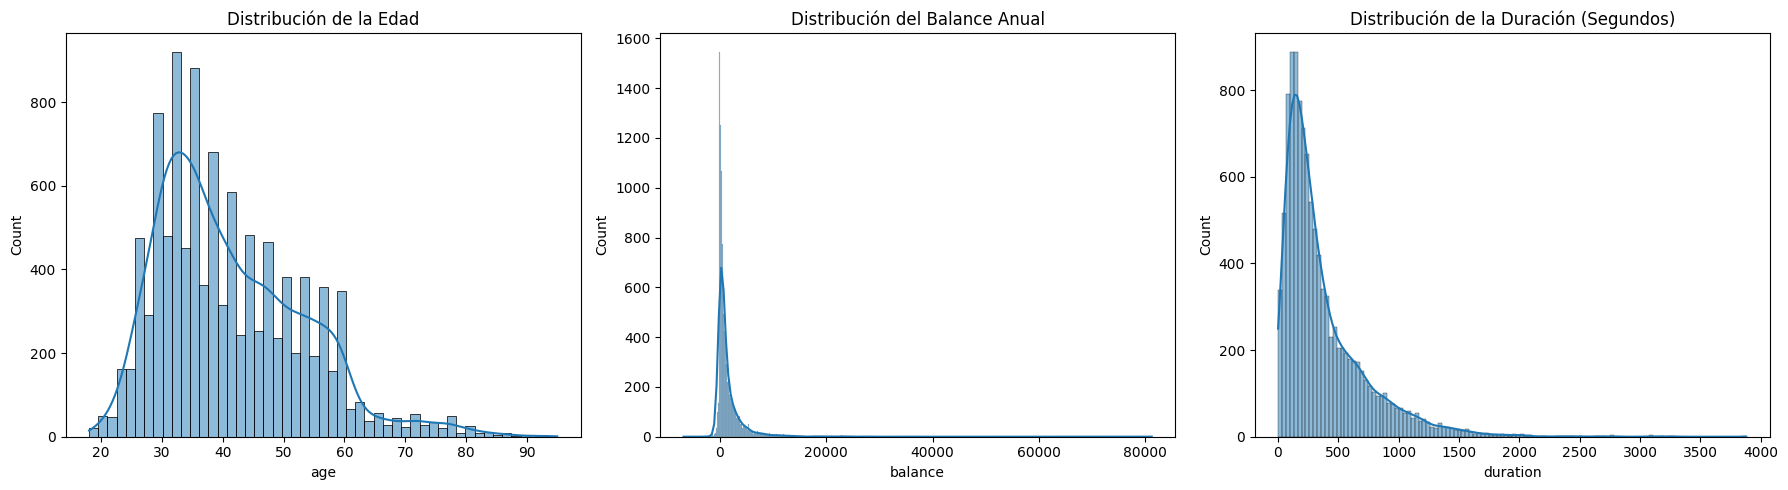

In [13]:
# Configurar el lienzo de gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# 1. Histograma de Edad
sns.histplot(df_marketing['age'], kde=True, ax=axes[0])
axes[0].set_title('Distribución de la Edad')

# 2. Histograma de Balance Bancario
sns.histplot(df_marketing['balance'], kde=True, ax=axes[1])
axes[1].set_title('Distribución del Balance Anual')

# 3. Histograma de Duración de la Llamada
sns.histplot(df_marketing['duration'], kde=True, ax=axes[2])
axes[2].set_title('Distribución de la Duración (Segundos)')

plt.tight_layout()
plt.show()

### 6. Anomalías en Balance vs. Éxito del Depósito
* Medianas similares (cerca de 550€): El nivel de saldo actual no discrimina si el cliente contratará o no el depóito.

* Outliers extremos: Ambos grupos registran tanto cuentas grandes (hasta $80,000) como cuentas sobregiradas (saldos negativos).

### 7. Anomalías en Duración vs. Éxito del Depósito
* Impacto de la Duración de la Llamada: A diferencia del balance, aquí se observa un patrón claro de comportamiento. La caja del grupo que contrató el depósito (yes) está visiblemente más elevada que la del grupo que lo rechazó (no). La mediana del grupo de éxito se sitúa cerca de los 500 segundos, mientras que la del grupo de rechazo cae drásticamente por debajo de los 200 segundos.

* Tiempo es conversión: Interacciones cortas implican descarte; llamadas largas validan el proceso de cierre de venta.



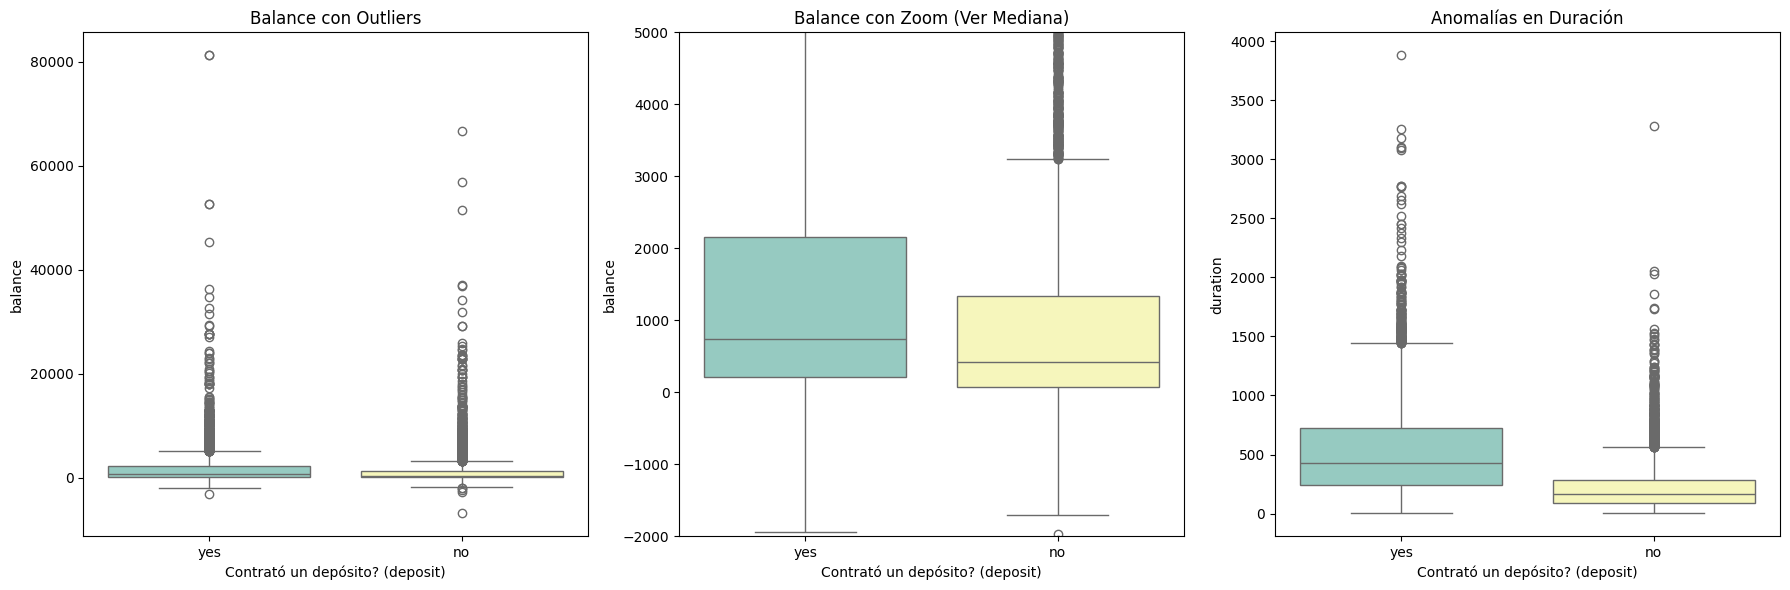

In [43]:
# Corrección: 1 fila, 3 columnas. Ajustamos figsize a (18, 6) para que no se amontonen
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Boxplot de Balance con outliers (Eje 0)
sns.boxplot(x='deposit', y='balance', data=df_marketing, ax=axes[0], palette='Set3', hue='deposit', legend=False)
axes[0].set_title('Balance con Outliers')
axes[0].set_xlabel('Contrató un depósito? (deposit)')

# 2. Boxplot de Balance con ZOOM (Eje 1)
sns.boxplot(x='deposit', y='balance', data=df_marketing, ax=axes[1], palette='Set3', hue='deposit', legend=False)
axes[1].set_ylim(-2000, 5000)  # Aplica el zoom solo a este gráfico
axes[1].set_title('Balance con Zoom (Ver Mediana)')
axes[1].set_xlabel('Contrató un depósito? (deposit)')

# 3. Boxplot de Duración de llamada (Eje 2)
sns.boxplot(x='deposit', y='duration', data=df_marketing, ax=axes[2], palette='Set3', hue='deposit', legend=False)
axes[2].set_title('Anomalías en Duración')
axes[2].set_xlabel('Contrató un depósito? (deposit)')

plt.tight_layout()
plt.show()


 ### Análisis de Correlación Lineal (Mapa de Calor)
* Independencia de Variables: Coeficientes generales muy cercanos a cero (-0.10 a 0.14). No existe riesgo de redundancia (multicolinealidad) para futuros modelos predictivos.

* Seguimiento de Clientes (pdays vs. previous): Correlación positiva moderada de 0.51. Confirma que a mayor cantidad de contactos pasados, mayor es el tiempo transcurrido desde la última campaña.
* Edad y Capital (age vs. balance): Relación positiva casi nula de 0.11. La edad del cliente no determina de forma lineal el saldo acumulado en su cuenta.
* Independencia Operativa (duration): Correlación lineal nula frente a las demás variables. El tiempo de la llamada no depende del perfil demográfico ni financiero del cliente.
* Presión Comercial (day vs. campaign): Correlación baja de 0.14. Sugiere un ligero incremento en la cantidad de contactos a medida que avanza el mes.

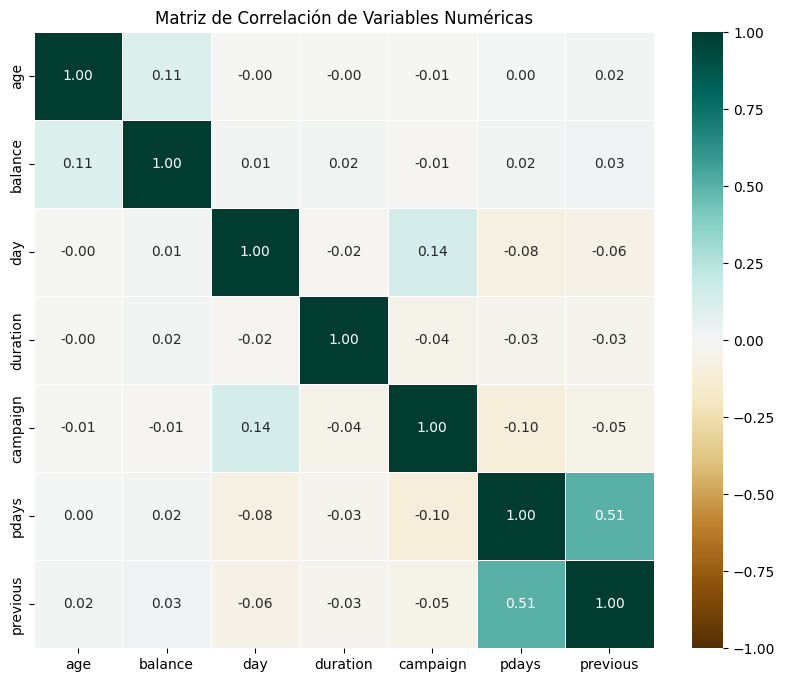

In [15]:
# 1. Seleccionar solo variables numéricas (excluyendo el 'id')
df_num = df_marketing.select_dtypes(include=[np.number]).drop(columns=['id'], errors='ignore')

# 2. Calcular la matriz de correlación de Pearson
matriz_corr = df_num.corr()

# 3. Dibujar el mapa de calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='BrBG', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

###  Análisis de Tendencias: Edad vs. Balance por Estado de Depósito
* Alta Densidad en Valores Bajos: El grueso de la muestra (puntos verdes y rojos) se concentra por debajo de los $10,000 de balance, sin importar la edad del cliente.
* Distribución de Conversión (yes): Los clientes que contrataron el depósito están dispersos de manera homogénea en todas las edades (de 20 a 90 años), confirmando que el éxito no se limita a un grupo generacional específico.
* Outliers Extremos de Capital: Se identifican casos aislados con saldos superiores a $40,000. Destaca un adulto mayor (~84 años) con el balance más alto del dataset (> $80,000) que sí contrató el producto.
* Ausencia de Patrón Lineal: La nube de puntos confirma visualmente lo observado en el mapa de calor; el saldo de la cuenta no se incrementa de forma lineal o proporcional conforme aumenta la edad.

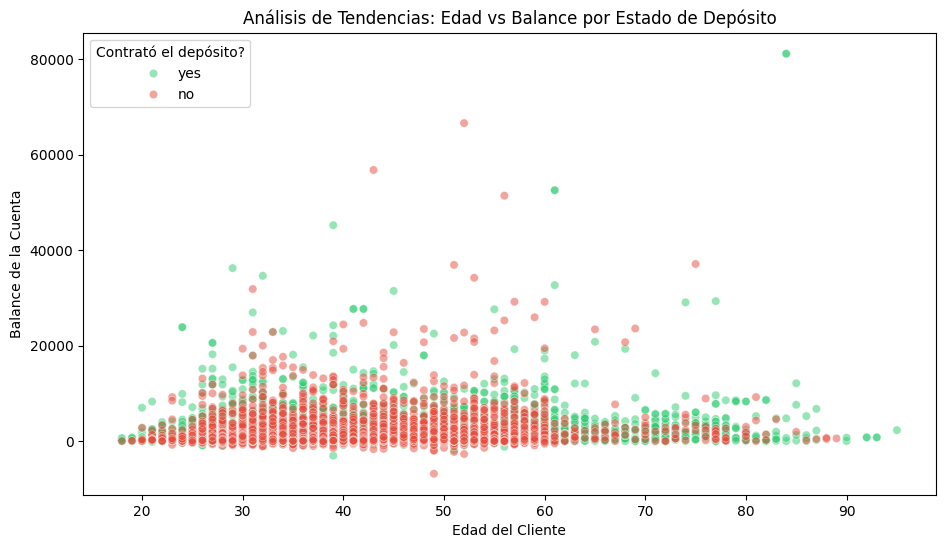

In [16]:
plt.figure(figsize=(11, 6))

# Gráfico de dispersión con diferenciación por color (hue)
sns.scatterplot(
    data=df_marketing, 
    x='age', 
    y='balance', 
    hue='deposit', 
    alpha=0.5, 
    palette={'yes': '#2ecc71', 'no': '#e74c3c'} # Verde para éxito, rojo para rechazo
)

plt.title('Análisis de Tendencias: Edad vs Balance por Estado de Depósito')
plt.xlabel('Edad del Cliente')
plt.ylabel('Balance de la Cuenta')
plt.legend(title='Contrató el depósito?')
plt.show()